# Real-Time Posture Correction System using Computer Vision and ML

This project detects human posture using computer vision and classifies it using a machine learning model.


## Problem Statement

Poor sitting posture during study or screen usage can lead to health issues like back pain and neck strain.

This project aims to:
- Detect posture using a webcam
- Classify posture as good or bad
- Provide feedback and alerts

## Technologies Used

- :contentReference[oaicite:0]{index=0} for pose detection
- OpenCV for image processing
- Scikit-learn for machine learning
- Matplotlib for visualization
- Pandas for dataset handling

## Project Workflow

1. Capture image/webcam input  
2. Detect body landmarks using MediaPipe  
3. Extract features (neck angle, torso angle)  
4. Train machine learning model  
5. Predict posture  
6. Display result and alerts  

In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.20

Found existing installation: mediapipe 0.10.20
Uninstalling mediapipe-0.10.20:
  Successfully uninstalled mediapipe-0.10.20
  Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl (35.6 MB)


In [ ]:
import mediapipe as mp

mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

print("MediaPipe working!")

MediaPipe working!


In [ ]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

## Feature Extraction

In this step, we extract meaningful features from body landmarks.
We calculate:
- Neck angle
- Torso angle

These features are used for machine learning.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

good_posture = np.random.normal(loc=[0.02, 0.4], scale=[0.01, 0.05], size=(50,2))
bad_posture = np.random.normal(loc=[0.08, 0.7], scale=[0.02, 0.08], size=(50,2))

good_labels = np.ones((50,1))
bad_labels = np.zeros((50,1))

data = np.vstack((np.hstack((good_posture, good_labels)),
                  np.hstack((bad_posture, bad_labels))))

df = pd.DataFrame(data, columns=["shoulder_slope", "neck_position", "label"])

df.head()

,shoulder_slope,neck_position,label
0,0.024967,0.393087,1.0
1,0.026477,0.476151,1.0
2,0.017658,0.388293,1.0
3,0.035792,0.438372,1.0
4,0.015305,0.427128,1.0


## Model Training

We use Logistic Regression to classify posture into:
- Good posture (1)
- Bad posture (0)

The model is trained using extracted features.

In [ ]:
X = df[["shoulder_slope", "neck_position"]]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- Confusion Matrix

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         8
         1.0       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Confusion Matrix

This graph shows how well the model predicts posture.

- True Positive: Correctly predicted good posture
- True Negative: Correctly predicted bad posture
- Errors show misclassification

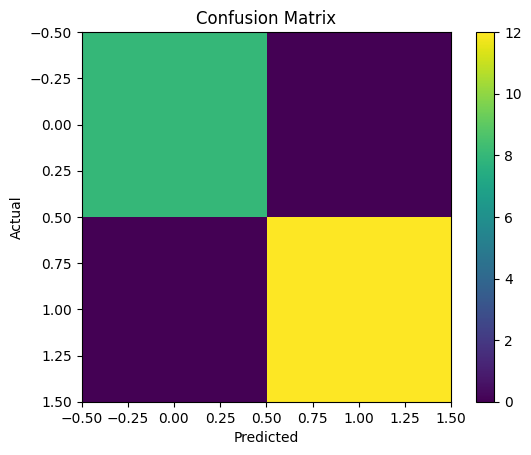

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving posture_1.jpg to posture_1.jpg


In [ ]:
for file_name in uploaded.keys():
    img = cv2.imread(file_name)

    features = extract_features(img)

    if features:
        prediction = model.predict([features])

        if prediction[0] == 1:
            print(f"{file_name}: Good Posture ✅")
    else:
        print(f"{file_name}: No pose detected")

posture_2 (2).jpg: Good Posture ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Real-Time Posture Detection

The system captures images from the webcam and:
- Extracts features
- Predicts posture
- Displays feedback

An alert is triggered if bad posture continues.

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import numpy as np
import cv2

def take_photo():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => setTimeout(resolve, 2000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])

    image = np.frombuffer(binary, dtype=np.uint8)
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)

    return image

In [ ]:
import time

while True:
    img = take_photo()

    features = extract_features(img)

    if features:
        prediction = model.predict([features])

        if prediction[0] == 1:
            print("✅ Good Posture")
        else:
            print("❌ Bad Posture - Sit Straight!")

    else:
        print("No pose detected")

    time.sleep(2)  # delay between frames

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


❌ Bad Posture - Sit Straight!


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


✅ Good Posture


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

## Conclusion

This project successfully:
- Detects posture using computer vision
- Classifies posture using machine learning
- Provides real-time feedback

It can be extended with:
- Screen distance monitoring
- Mobile application integration